 Import libraries

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

Load  dataset


In [59]:
df = pd.read_csv(
    "disease_prediction.csv"
)

print("Dataset Shape:", df.shape)

display(df.head())

Dataset Shape: (4998, 16)


,fever,cough,headache,nausea,vomiting,fatigue,sore_throat,chills,body_pain,loss_of_appetite,abdominal_pain,diarrhea,sweating,rapid_breathing,dizziness,label
0,1,1,1,1,0,0,0,1,1,1,1,0,0,0,0,Typhoid
1,1,0,1,0,1,0,1,1,0,0,1,0,1,1,0,Malaria
2,1,1,1,1,1,1,0,0,0,1,1,1,1,0,1,Typhoid
3,1,1,1,1,0,1,0,0,0,0,0,0,1,0,0,Malaria
4,1,1,1,1,1,0,0,1,1,0,1,1,1,0,1,Typhoid


Check Dataset

In [60]:
print("Dataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDisease Distribution:")
print(df["label"].value_counts())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4998 entries, 0 to 4997
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   fever             4998 non-null   int64 
 1   cough             4998 non-null   int64 
 2   headache          4998 non-null   int64 
 3   nausea            4998 non-null   int64 
 4   vomiting          4998 non-null   int64 
 5   fatigue           4998 non-null   int64 
 6   sore_throat       4998 non-null   int64 
 7   chills            4998 non-null   int64 
 8   body_pain         4998 non-null   int64 
 9   loss_of_appetite  4998 non-null   int64 
 10  abdominal_pain    4998 non-null   int64 
 11  diarrhea          4998 non-null   int64 
 12  sweating          4998 non-null   int64 
 13  rapid_breathing   4998 non-null   int64 
 14  dizziness         4998 non-null   int64 
 15  label             4998 non-null   object
dtypes: int64(15), object(1)
memory usage: 6

Separate Features and Target

In [61]:
X = df.drop(columns=["label"])

y = df["label"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (4998, 15)
Target shape: (4998,)


Train-Test Split

In [62]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 3998
Testing samples: 1000


 Logistic Regression model


In [63]:
LR_model = LogisticRegression(
    max_iter=2000,
    solver="lbfgs"
)

LR_model.fit(X_train, y_train)

print("Logistic Regression training completed!")

Logistic Regression training completed!


 Prediction

In [64]:
y_pred = LR_model.predict(X_test)

print("Prediction completed!")

Prediction completed!


Accuracy

In [65]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy (%):", accuracy * 100)

Accuracy: 0.886
Accuracy (%): 88.6


 Precision

In [66]:
precision = precision_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

print("Precision:", precision)
print("Precision (%):", precision * 100)

Precision: 0.8858491707633298
Precision (%): 88.58491707633299


Recall

In [67]:
recall = recall_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

print("Recall:", recall)
print("Recall (%):", recall * 100)

Recall: 0.886
Recall (%): 88.6


F1 Score

In [68]:
f1 = f1_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

print("F1 Score:", f1)
print("F1 Score (%):", f1 * 100)

F1 Score: 0.8857362115488397
F1 Score (%): 88.57362115488398


All Metrics

In [69]:
print(" LOGISTIC REGRESSION RESULTS")

print(f"Accuracy  : {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Precision : {precision:.4f} ({precision*100:.2f}%)")
print(f"Recall    : {recall:.4f} ({recall*100:.2f}%)")
print(f"F1 Score  : {f1:.4f} ({f1*100:.2f}%)")


 LOGISTIC REGRESSION RESULTS
Accuracy  : 0.8860 (88.60%)
Precision : 0.8858 (88.58%)
Recall    : 0.8860 (88.60%)
F1 Score  : 0.8857 (88.57%)


Classification Report

In [70]:
print("Classification Report")

print(
    classification_report(
        y_test,
        y_pred,
        zero_division=0
    )
)

Classification Report
              precision    recall  f1-score   support

     Malaria       0.87      0.83      0.85       333
   Pneumonia       0.91      0.91      0.91       333
     Typhoid       0.88      0.91      0.89       334

    accuracy                           0.89      1000
   macro avg       0.89      0.89      0.89      1000
weighted avg       0.89      0.89      0.89      1000



Confusion Matrix

In [71]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[278  24  31]
 [ 18 304  11]
 [ 25   5 304]]


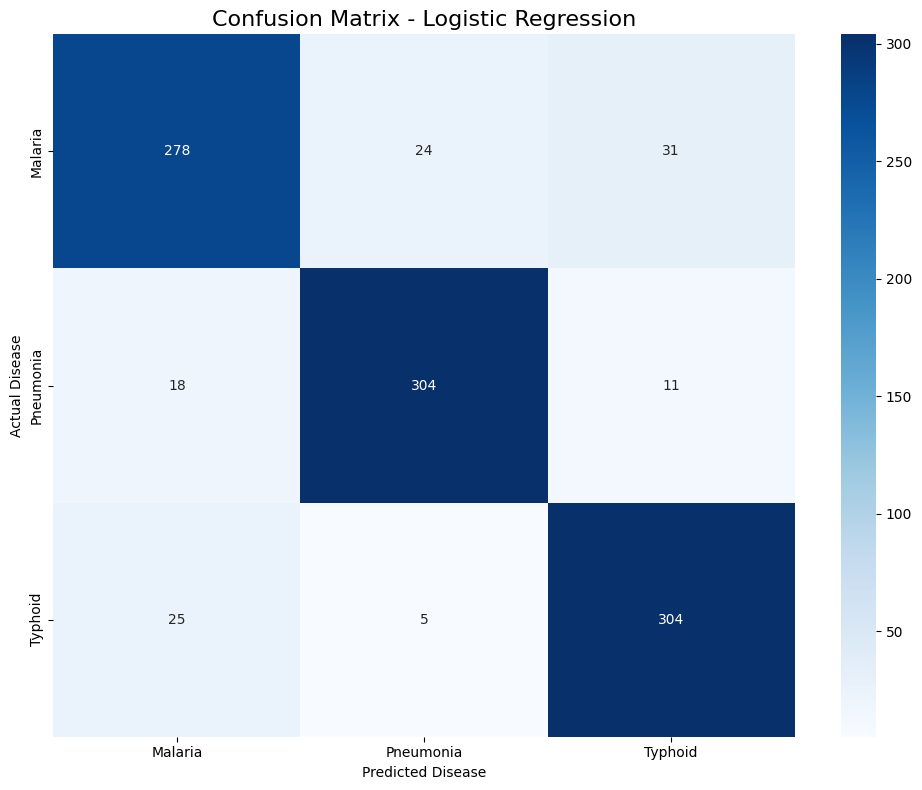

In [72]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=sorted(y.unique()),
    yticklabels=sorted(y.unique())
)

plt.title("Confusion Matrix - Logistic Regression", fontsize=16)
plt.xlabel("Predicted Disease")
plt.ylabel("Actual Disease")

plt.tight_layout()
plt.show()

Actual vs Predicted Disease

In [73]:
results = pd.DataFrame({
    "Actual Disease": y_test.values,
    "Predicted Disease": y_pred
})

display(results.head(30))

,Actual Disease,Predicted Disease
0,Typhoid,Typhoid
1,Malaria,Pneumonia
2,Typhoid,Typhoid
3,Malaria,Malaria
4,Pneumonia,Pneumonia
5,Malaria,Pneumonia
6,Malaria,Malaria
7,Typhoid,Typhoid
8,Pneumonia,Pneumonia
9,Typhoid,Typhoid


 New Patient Disease Prediction

In [74]:
new_symptoms = [
    "fever",
    "cough",
    "headache",
    "nausea"
]

new_patient = pd.DataFrame(
    0,
    index=[0],
    columns=X.columns
)

for symptom in new_symptoms:
    if symptom in new_patient.columns:
        new_patient.loc[0, symptom] = 1
    else:
        print(f"Warning: '{symptom}' is not a feature in the dataset.")

prediction = LR_model.predict(new_patient)

probabilities = LR_model.predict_proba(new_patient)

predicted_disease = prediction[0]
confidence = np.max(probabilities) * 100

print("NEW PATIENT PREDICTION")

print("Symptoms:", new_symptoms)
print("Predicted Disease:", predicted_disease)
print(f"Confidence: {confidence:.2f}%")

NEW PATIENT PREDICTION
Symptoms: ['fever', 'cough', 'headache', 'nausea']
Predicted Disease: Pneumonia
Confidence: 37.16%
